# ENTRENANDO MODELO DE ML PARA CLASIFICIAR INGRESANTES A UNIVERSIDAD
## DATASET: https://www.datosabiertos.gob.pe/dataset/postulantes-al-concurso-de-admisi%C3%B3n-de-la-universidad-nacional-de-ingenier%C3%ADa-uni

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [3]:
df = pd.read_csv('/content/uni_cleaned.csv')
df

,COLEGIO_DEPA,ESPECIALIDAD,SEXO,INGRESO,egreso_postulacion,edad
0,LIMA,INGENIERÍA DE SISTEMAS,MASCULINO,NO,1,17
1,ÁNCASH,INGENIERÍA DE TELECOMUNICACIONES,FEMENINO,NO,4,20
2,LIMA,INGENIERÍA MECÁNICA,MASCULINO,NO,5,21
3,LIMA,INGENIERÍA ELECTRÓNICA,MASCULINO,NO,3,19
4,LIMA,ARQUITECTURA,FEMENINO,NO,1,17
...,...,...,...,...,...,...
42230,LIMA,INGENIERÍA CIVIL,MASCULINO,NO,4,21
42231,CALLAO,INGENIERÍA CIVIL,FEMENINO,NO,2,19
42232,AYACUCHO,ARQUITECTURA,FEMENINO,NO,1,17
42233,LIMA,ARQUITECTURA,FEMENINO,NO,2,19


## PASO 3 - PREPROCESAMIENTO DE VARIABLES NÚMERICAS

In [ ]:
# no es necesario

# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [4]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['COLEGIO_DEPA', 'ESPECIALIDAD', 'SEXO', 'INGRESO'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [5]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
COLEGIO_DEPA
LIMA             31949
CALLAO            1973
JUNIN              766
ICA                645
AYACUCHO           642
PUNO               612
JUNÍN              556
ANCASH             513
CAJAMARCA          506
LAMBAYEQUE         506
ÁNCASH             444
CUSCO              308
HUANCAVELICA       258
APURIMAC           248
AMAZONAS           243
HUANUCO            238
PASCO              233
AREQUIPA           212
HUÁNUCO            190
APURÍMAC           189
LA LIBERTAD        171
PIURA              143
TACNA              131
SAN MARTIN         128
UCAYALI            101
SAN MARTÍN          99
LORETO              76
MOQUEGUA            49
MADRE DE DIOS       44
TUMBES              39
VENEZUELA            6
ECUADOR              6
ARGENTINA            4
ESPAÑA               2
CHILE                2
CANADA               1
ITALIA               1
COLOMBIA             1
Name: count, dtype: int64
************************************

In [6]:
ordinal_cols = ['SEXO','INGRESO']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['SEXO', 'INGRESO'] ['ESPECIALIDAD', 'COLEGIO_DEPA']


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [7]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [8]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['SEXO', 'INGRESO']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['ESPECIALIDAD', 'COLEGIO_DEPA'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [10]:
import numpy as np

transformed_data = transformer.fit_transform(df)

# If the transformer outputs a sparse matrix (e.g., from OneHotEncoder), convert it to a dense array.
if hasattr(transformed_data, 'toarray'):
    transformed_data = transformed_data.toarray()

# Check if the transformed data is a 2D array with 1 column, where each element is an array (row)
# This specific condition addresses the ValueError: Shape of passed values is (N, 1), indices imply (N, M).
if transformed_data.ndim == 2 and transformed_data.shape[1] == 1 and transformed_data.dtype == object and isinstance(transformed_data[0,0], (np.ndarray, list)):
    # Stack the inner arrays from the single column to form the correct 2D array
    transformed_data = np.vstack(transformed_data[:, 0])

data_transformed_df = (
    pd.DataFrame(
        transformed_data,
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__SEXO,ordinalencoder__INGRESO,onehotencoder__ESPECIALIDAD_ARQUITECTURA,onehotencoder__ESPECIALIDAD_CIENCIA DE LA COMPUTACIÓN,onehotencoder__ESPECIALIDAD_FÍSICA,onehotencoder__ESPECIALIDAD_INGENIERÍA AMBIENTAL,onehotencoder__ESPECIALIDAD_INGENIERÍA CIVIL,onehotencoder__ESPECIALIDAD_INGENIERÍA DE CIBERSEGURIDAD,onehotencoder__ESPECIALIDAD_INGENIERÍA DE HIGIENE Y SEGURIDAD INDUSTRIAL,onehotencoder__ESPECIALIDAD_INGENIERÍA DE MINAS,...,onehotencoder__COLEGIO_DEPA_PUNO,onehotencoder__COLEGIO_DEPA_SAN MARTIN,onehotencoder__COLEGIO_DEPA_SAN MARTÍN,onehotencoder__COLEGIO_DEPA_TACNA,onehotencoder__COLEGIO_DEPA_TUMBES,onehotencoder__COLEGIO_DEPA_UCAYALI,onehotencoder__COLEGIO_DEPA_VENEZUELA,onehotencoder__COLEGIO_DEPA_ÁNCASH,remainder__egreso_postulacion,remainder__edad
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,20.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,21.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,19.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42230,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,21.0
42231,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0
42232,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
42233,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0


In [11]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,SEXO,INGRESO,ESPECIALIDAD_ARQUITECTURA,ESPECIALIDAD_CIENCIA DE LA COMPUTACIÓN,ESPECIALIDAD_FÍSICA,ESPECIALIDAD_INGENIERÍA AMBIENTAL,ESPECIALIDAD_INGENIERÍA CIVIL,ESPECIALIDAD_INGENIERÍA DE CIBERSEGURIDAD,ESPECIALIDAD_INGENIERÍA DE HIGIENE Y SEGURIDAD INDUSTRIAL,ESPECIALIDAD_INGENIERÍA DE MINAS,...,COLEGIO_DEPA_PUNO,COLEGIO_DEPA_SAN MARTIN,COLEGIO_DEPA_SAN MARTÍN,COLEGIO_DEPA_TACNA,COLEGIO_DEPA_TUMBES,COLEGIO_DEPA_UCAYALI,COLEGIO_DEPA_VENEZUELA,COLEGIO_DEPA_ÁNCASH,egreso_postulacion,edad
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,20.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,21.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,19.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42230,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,21.0
42231,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0
42232,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
42233,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0


In [12]:
data_transformed_df.dtypes

,0
SEXO,float64
INGRESO,float64
ESPECIALIDAD_ARQUITECTURA,float64
ESPECIALIDAD_CIENCIA DE LA COMPUTACIÓN,float64
ESPECIALIDAD_FÍSICA,float64
...,...
COLEGIO_DEPA_UCAYALI,float64
COLEGIO_DEPA_VENEZUELA,float64
COLEGIO_DEPA_ÁNCASH,float64
egreso_postulacion,float64


In [13]:
data_transformed_df.to_csv('uni_transformed.csv',index=None)

In [14]:
df = pd.read_csv('/content/uni_transformed.csv')
df

,SEXO,INGRESO,ESPECIALIDAD_ARQUITECTURA,ESPECIALIDAD_CIENCIA DE LA COMPUTACIÓN,ESPECIALIDAD_FÍSICA,ESPECIALIDAD_INGENIERÍA AMBIENTAL,ESPECIALIDAD_INGENIERÍA CIVIL,ESPECIALIDAD_INGENIERÍA DE CIBERSEGURIDAD,ESPECIALIDAD_INGENIERÍA DE HIGIENE Y SEGURIDAD INDUSTRIAL,ESPECIALIDAD_INGENIERÍA DE MINAS,...,COLEGIO_DEPA_PUNO,COLEGIO_DEPA_SAN MARTIN,COLEGIO_DEPA_SAN MARTÍN,COLEGIO_DEPA_TACNA,COLEGIO_DEPA_TUMBES,COLEGIO_DEPA_UCAYALI,COLEGIO_DEPA_VENEZUELA,COLEGIO_DEPA_ÁNCASH,egreso_postulacion,edad
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,20.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,21.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,19.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42230,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,21.0
42231,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0
42232,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,17.0
42233,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,19.0


In [16]:
variable_dep = 'INGRESO'

In [18]:
corr_matrix = df.corr()
corr_dep = corr_matrix[[variable_dep]].sort_values(by=variable_dep,ascending=False)
corr_dep

,INGRESO
INGRESO,1.000000
egreso_postulacion,0.151937
edad,0.141068
SEXO,0.076919
ESPECIALIDAD_FÍSICA,0.064353
...,...
COLEGIO_DEPA_APURIMAC,-0.016176
ESPECIALIDAD_INGENIERÍA INDUSTRIAL,-0.026781
ESPECIALIDAD_INGENIERÍA CIVIL,-0.054372
ESPECIALIDAD_INGENIERÍA DE SISTEMAS,-0.061013


In [19]:
cols = corr_dep.index.tolist()
cols.remove(variable_dep)
cols

['egreso_postulacion',
 'edad',
 'SEXO',
 'ESPECIALIDAD_FÍSICA',
 'ESPECIALIDAD_INGENIERÍA FÍSICA',
 'ESPECIALIDAD_CIENCIA DE LA COMPUTACIÓN',
 'ESPECIALIDAD_INGENIERÍA QUÍMICA',
 'ESPECIALIDAD_INGENIERÍA SANITARIA',
 'ESPECIALIDAD_INGENIERÍA ESTADÍSTICA',
 'ESPECIALIDAD_INGENIERÍA ELECTRÓNICA',
 'ESPECIALIDAD_INGENIERÍA AMBIENTAL',
 'ESPECIALIDAD_INGENIERÍA DE MINAS',
 'ESPECIALIDAD_MATEMÁTICA',
 'COLEGIO_DEPA_LIMA',
 'ESPECIALIDAD_INGENIERÍA ECONÓMICA',
 'ESPECIALIDAD_INGENIERÍA DE TELECOMUNICACIONES',
 'ESPECIALIDAD_INGENIERÍA GEOLÓGICA',
 'ESPECIALIDAD_INGENIERÍA ELÉCTRICA',
 'ESPECIALIDAD_INGENIERÍA MECÁNICA-ELÉCTRICA',
 'ESPECIALIDAD_INGENIERÍA PETROQUÍMICA',
 'COLEGIO_DEPA_JUNÍN',
 'ESPECIALIDAD_INGENIERÍA DE HIGIENE Y SEGURIDAD INDUSTRIAL',
 'ESPECIALIDAD_QUÍMICA',
 'ESPECIALIDAD_INGENIERÍA DE CIBERSEGURIDAD',
 'COLEGIO_DEPA_JUNIN',
 'COLEGIO_DEPA_LAMBAYEQUE',
 'COLEGIO_DEPA_ESPAÑA',
 'ESPECIALIDAD_INGENIERÍA DE PETRÓLEO Y GAS NATURAL',
 'ESPECIALIDAD_INGENIERÍA METALÚRGICA',
 

In [20]:
X = df[cols].values
y = df[variable_dep].values.reshape(-1,1)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

## 2 - DEFINIMOS LOS MODELOS A EVALUAR

In [24]:
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf')
}

## 3 - CREAMOS FUNCIÓN DE EVALUACIÓN

In [26]:
def evaluar_clasificador(modelo, nombre):
    modelo.fit(X_train, y_train.ravel())
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Accuracy: {accuracy:.4f}')
    #print(classification_report(y_test, y_pred))
    return accuracy

## 4 - ENTRENAMOS Y COMPARAMOS MODELOS

In [27]:
resultados_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    resultados_clasificacion[nombre] = evaluar_clasificador(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo_clasificacion = max(resultados_clasificacion, key=resultados_clasificacion.get)
print(f'\nEl mejor modelo es: {mejor_modelo_clasificacion} con un Accuracy de {resultados_clasificacion[mejor_modelo_clasificacion]:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Regresión Logística:
Accuracy: 0.8386


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest:
Accuracy: 0.8277


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)



k-Nearest Neighbors:
Accuracy: 0.8229


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Gradient Boosting:
Accuracy: 0.8405


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



SVM (RBF):
Accuracy: 0.8392

El mejor modelo es: Gradient Boosting con un Accuracy de 0.8405


## 5. GRAFICAMOS RESULTADOS

/tmp/ipython-input-219317408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')


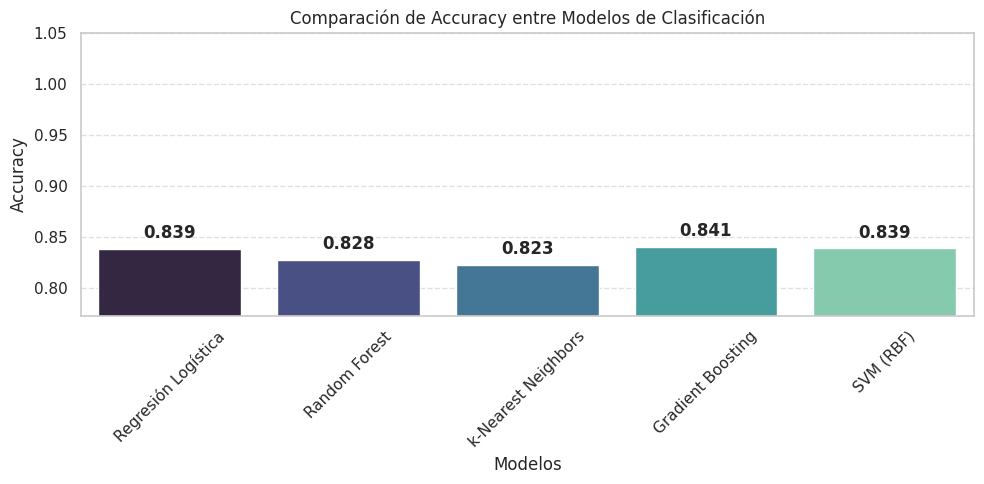

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación del Accuracy entre modelos de clasificación
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')

# Agregar etiquetas en cada barra
for index, value in enumerate(resultados_clasificacion.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(min(resultados_clasificacion.values()) - 0.05, 1.05)
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## CREAMOS UNA MATRIZ DE CONFUSIÓN

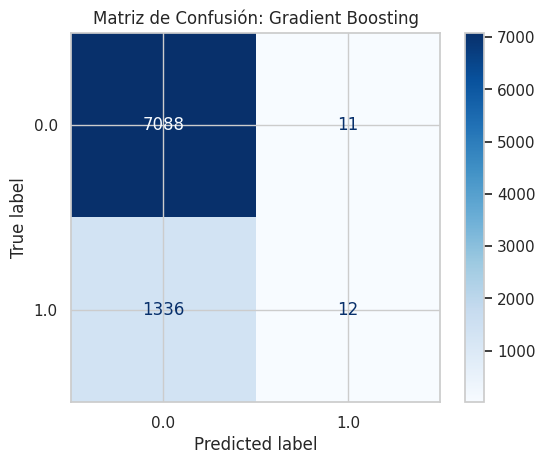

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación del mejor modelo de clasificación
modelo_clasificacion_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]
y_pred_clasificacion = modelo_clasificacion_seleccionado.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasificacion)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_clasificacion_seleccionado.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión: {mejor_modelo_clasificacion}')
plt.show()